# Импорты

In [1]:
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import torch
import pandas as pd
import matplotlib.pyplot as plt

print(torch.__version__, torch.cuda.is_available(), torch.cuda.get_device_name(0))

2.13.0+cu130 True NVIDIA GeForce RTX 2060 SUPER


# Тесты корректности (задания 3.1 и 3.2)

In [2]:
!pytest ../tests/test_flash_attention.py -v

============================= test session starts ==============================
platform linux -- Python 3.13.5, pytest-9.1.1, pluggy-1.6.0 -- /home/ddmitriev/labs/MNNA-2026-labs-DmitrievDM/.venv/bin/python3
cachedir: .pytest_cache
rootdir: /home/ddmitriev/labs/MNNA-2026-labs-DmitrievDM
plugins: hydra-core-1.3.6, anyio-4.14.2
collected 8 items                                                              

../tests/test_flash_attention.py::test_flash_attention_forward[128-True] PASSED [ 12%]
../tests/test_flash_attention.py::test_flash_attention_forward[128-False] PASSED [ 25%]
../tests/test_flash_attention.py::test_flash_attention_forward[300-True] PASSED [ 37%]
../tests/test_flash_attention.py::test_flash_attention_forward[300-False] PASSED [ 50%]
../tests/test_flash_attention.py::test_flash_attention_forward[512-True] PASSED [ 62%]
../tests/test_flash_attention.py::test_flash_attention_forward[512-False] PASSED [ 75%]
../tests/test_flash_attention.py::test_flash_attention_backward[T

# Демонстрация FlashAttention как слоя

In [3]:
from src.backend.flash_attention import FlashAttention

layer = FlashAttention(causal=True)
q = torch.randn(1, 8, 128, 64, device="cuda", dtype=torch.float16, requires_grad=True)
k = torch.randn(1, 8, 128, 64, device="cuda", dtype=torch.float16, requires_grad=True)
v = torch.randn(1, 8, 128, 64, device="cuda", dtype=torch.float16, requires_grad=True)

out = layer(q, k, v)
print("output shape:", out.shape)

out.sum().backward()
print("dQ shape:", q.grad.shape)

output shape: torch.Size([1, 8, 128, 64])
dQ shape: torch.Size([1, 8, 128, 64])


# Бенчмарки (задание 3.3)

In [4]:
from src.backend.benchmark_utils import run_benchmark_suite

results = run_benchmark_suite(seq_lens=[256, 512, 1024, 2048, 4096], causal=True)
df = pd.DataFrame(results)

df["fwd_speedup"] = df["ref_fwd_ms"] / df["flash_fwd_ms"]
df["fwd_memory_ratio"] = df["ref_fwd_mem_mb"] / df["flash_fwd_mem_mb"]
df["bwd_speedup"] = df["ref_bwd_ms"] / df["flash_bwd_ms"]
df["bwd_memory_ratio"] = df["ref_bwd_mem_mb"] / df["flash_bwd_mem_mb"]

df

,seq_len,causal,flash_fwd_ms,flash_fwd_mem_mb,ref_fwd_ms,ref_fwd_mem_mb,flash_bwd_ms,flash_bwd_mem_mb,ref_bwd_ms,ref_bwd_mem_mb,fwd_speedup,fwd_memory_ratio,bwd_speedup,bwd_memory_ratio
0,256,True,2.604100,4.90625,0.333594,21.0625,10.359126,17.0625,1.758254,39.1875,0.128103,4.292994,0.169730,2.296703
1,512,True,8.410848,25.18750,0.646985,57.3750,35.908252,33.2500,1.659862,93.3750,0.076923,2.277916,0.046225,2.808271
2,1024,True,31.610065,33.25000,2.496836,162.1250,133.286336,49.3750,6.088960,298.1250,0.078989,4.875940,0.045683,6.037975
3,2048,True,121.880998,49.37500,9.982001,565.1250,511.647363,81.6250,24.391915,1093.1250,0.081900,11.445570,0.047673,13.392037
4,4096,True,479.969043,81.62500,46.032007,2145.1250,2008.942708,146.1250,102.936711,4225.1250,0.095906,26.280245,0.051239,28.914457


# Визуализация

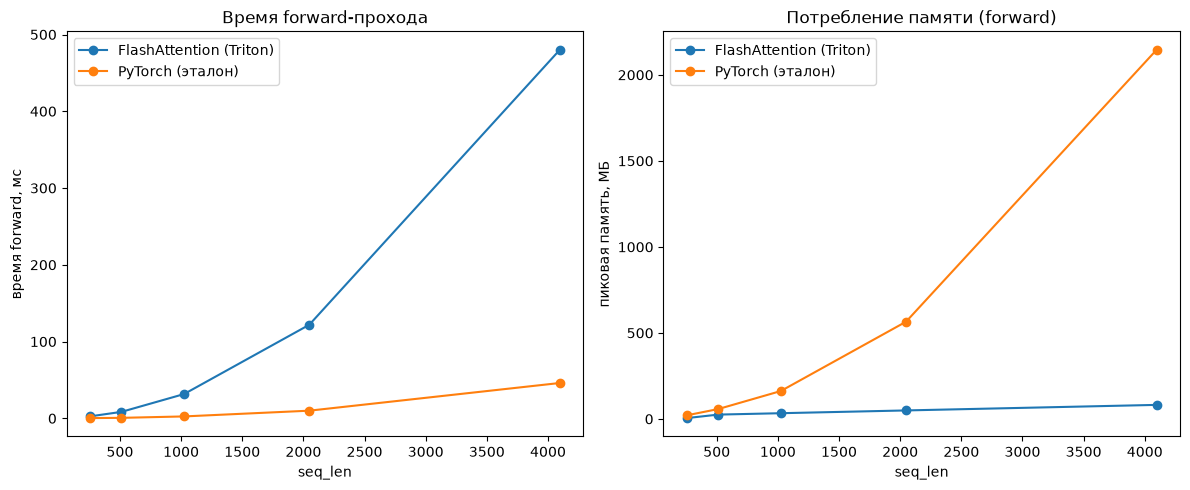

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(df["seq_len"], df["flash_fwd_ms"], marker="o", label="FlashAttention (Triton)")
axes[0].plot(df["seq_len"], df["ref_fwd_ms"], marker="o", label="PyTorch (эталон)")
axes[0].set_xlabel("seq_len")
axes[0].set_ylabel("время forward, мс")
axes[0].set_title("Время forward-прохода")
axes[0].legend()

axes[1].plot(df["seq_len"], df["flash_fwd_mem_mb"], marker="o", label="FlashAttention (Triton)")
axes[1].plot(df["seq_len"], df["ref_fwd_mem_mb"], marker="o", label="PyTorch (эталон)")
axes[1].set_xlabel("seq_len")
axes[1].set_ylabel("пиковая память, МБ")
axes[1].set_title("Потребление памяти (forward)")
axes[1].legend()

plt.tight_layout()
plt.show()